In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
# importing required libraries
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import matplotlib.pyplot as plt

In [13]:
# Custom Dataset Class for Multilabel Classification with NA Handling
class MultiLabelDataset(Dataset):
    def __init__(self, image_dir, label_file, transform=None):
        self.image_dir = image_dir
        self.transform = transform
        self.samples = []

        image_files = set(os.listdir(image_dir))

        with open(label_file, 'r') as f:
            lines = f.readlines()

        for line in lines:
            line = line.strip()
            if line == "":
                continue

            parts = line.split()
            img_name = parts[0]

            if img_name not in image_files:
                continue

            labels = parts[1:]

            target = []
            mask = []

            for val in labels:
                if val == "NA":
                    target.append(0.0)
                    mask.append(0.0)
                else:
                    target.append(float(val))
                    mask.append(1.0)

            self.samples.append(
                (img_name,
                 torch.tensor(target, dtype=torch.float32),
                 torch.tensor(mask, dtype=torch.float32))
            )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_name, target, mask = self.samples[idx]

        img_path = os.path.join(self.image_dir, img_name)
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, target, mask

In [14]:
# Image Preprocessing and Transformation Pipeline
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

In [15]:
# Create Dataset & DataLoader
dataset = MultiLabelDataset(image_dir, label_file, transform)
print("Clean samples:", len(dataset))

dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

Clean samples: 972


In [16]:
# Compute Class Imbalance and pos_weight
pos_counts = torch.zeros(4)
valid_counts = torch.zeros(4)

for _, target, mask in dataset:
    pos_counts += target * mask
    valid_counts += mask

neg_counts = valid_counts - pos_counts

print("Positive counts:", pos_counts)
print("Negative counts:", neg_counts)

Positive counts: tensor([786., 710., 464.,  68.])
Negative counts: tensor([106., 171., 416., 812.])


In [17]:
pos_weight = neg_counts / (pos_counts + 1e-5)
print("pos_weight:", pos_weight)

pos_weight: tensor([ 0.1349,  0.2408,  0.8966, 11.9412])


In [18]:
# Set Device (CPU/GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [19]:
# Load Pretrained ResNet18 and Modify Final Layer
model = models.resnet18(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 107MB/s]


In [20]:
model.fc

Linear(in_features=512, out_features=1000, bias=True)

In [21]:
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 4)  # 4 attributes

In [22]:
model = model.to(device)

In [23]:
# Define Loss Function with pos_weight
criterion = nn.BCEWithLogitsLoss(
    reduction='none',
    pos_weight=pos_weight.to(device)
)

In [24]:
# Define Optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [25]:
# Training Loop
num_epochs = 5
loss_history = []
iteration_number = []

model.train()

iteration = 0

for epoch in range(num_epochs):
    for images, targets, masks in dataloader:

        images = images.to(device)
        targets = targets.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        # Compute element-wise BCE loss
        loss = criterion(outputs, targets)

        # Apply mask (ignore NA labels)
        masked_loss = loss * masks

        # Take mean only over valid labels
        final_loss = masked_loss.sum() / masks.sum()

        final_loss.backward()
        optimizer.step()

        loss_history.append(final_loss.item())
        iteration_number.append(iteration)

        iteration += 1

    print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {final_loss.item():.4f}")

Epoch [1/5] Loss: 0.4985
Epoch [2/5] Loss: 0.8678
Epoch [3/5] Loss: 0.6088
Epoch [4/5] Loss: 0.6408
Epoch [5/5] Loss: 0.4106


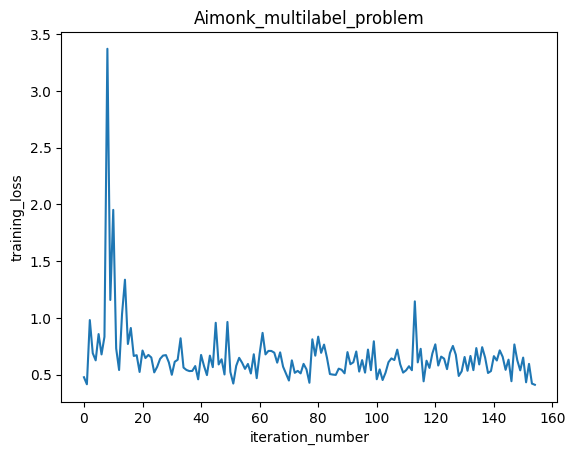

In [26]:
# Plot Training Loss Curve
plt.figure()
plt.plot(iteration_number, loss_history)
plt.title("Aimonk_multilabel_problem")
plt.xlabel("iteration_number")
plt.ylabel("training_loss")
plt.show()

In [27]:
# # Save Trained Model
torch.save(model.state_dict(), "multilabel_model.pth")

In [28]:
# Single Image Inference Function
def predict_image(image_path, model, transform):
    model.eval()

    image = Image.open(image_path).convert("RGB")
    image = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image)
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()

    attributes = []
    for i, val in enumerate(preds[0]):
        if val == 1:
            attributes.append(f"Attr{i+1}")

    print("Attributes present:", attributes)

In [29]:
# Inference Function Returning Attribute List
predict_image(
    "/content/drive/MyDrive/multilabel/images/image_0.jpg",
    model,
    transform
)

Attributes present: ['Attr2']


In [30]:
# Create Prediction Function That Returns List
def predict_image_return(image_path, model, transform):
    model.eval()

    image = Image.open(image_path).convert("RGB")
    image = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image)
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()

    attributes = []
    for i, val in enumerate(preds[0]):
        if val == 1:
            attributes.append(f"Attr{i+1}")

    return attributes

In [31]:
# Predict All Images & Save to CSV
import csv

output_file = "all_predictions.csv"

with open(output_file, mode='w', newline='') as file:
    writer = csv.writer(file)

    # Header
    writer.writerow(["Image_Name", "Predicted_Attributes"])

    for img_name in os.listdir(image_dir):
        img_path = os.path.join(image_dir, img_name)

        preds = predict_image_return(img_path, model, transform)

        writer.writerow([img_name, ",".join(preds)])

print("All predictions saved to all_predictions.csv")

All predictions saved to all_predictions.csv
